<a href="https://colab.research.google.com/github/as-arthur/Coding_Camp/blob/main/my_Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Fathurrahman
- **Email:** muhammad.220170212@mhs.unimal.ac.id
- **ID Dicoding:** arthurism

## Menentukan Pertanyaan Bisnis

- Bagaimana pendapatan yang dihasilkan pada tahun 2018? dan bagaimana pertumbuhannya dibandingkan dengan tahun 2017?

- Kategori produk mana yang memberikan kontribusi pendapatan tertinggi dan terendah pada tahun 2018?

# Menghubungkan Google Collab dengan G-Drive

In [ ]:
from google.colab import drive
drive.mount('/content/MyDrive')


Mounted at /content/MyDrive


## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

In [ ]:
costumers_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/customers_dataset.csv")
costumers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
geolocation_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/geolocation_dataset.csv")
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [ ]:
order_items_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
order_payments_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/order_payments_dataset.csv")
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
order_reviews_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/order_reviews_dataset.csv")
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
orders_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
product_category_name_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/product_category_name_translation.csv")
product_category_name_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
products_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
sellers_df = pd.read_csv("/content/MyDrive/MyDrive/E-Commerce Public Dataset/sellers_dataset.csv")
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**
<br>
Data terdiri dari 9 dataset yakni costumer, geolocation, order item, payment dan review, orders (informasi status dan waktu dari order), kategori produk, list produk dan penjual.

- **costumer** memiliki data seperti: **customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state**

- **geolocation** memiliki data : **geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state**

- **order_items** memiliki data : **order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value**

- **order_payments** memiliki data : **order_id, payment_sequential, payment_type, payment_installments, payment_value**

- **order_reviews** memiliki data : **review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp**

- **orders** memiliki data : **order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date**

- **product_category** memiliki data : **product_category_name, product_category_name_english**

- **products** memiliki data : **product_id, product_category_name,product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm**

- **sellers** memiliki data : **seller_id, seller_zip_code_prefix, seller_city, seller_state**


### Assessing Data

#Menilai Data costumers_df

In [ ]:
costumers_df.info()
print("duplikasi : " , costumers_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
duplikasi :  0


In [ ]:
costumers_df.describe(include="all")

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


# Menilai data geolocation_df

In [ ]:
geolocation_df.info()
print("duplikasi : " , geolocation_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB
duplikasi :  261831


In [ ]:
geolocation_df.describe(include="all")

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


# Menilai data order_items_df

In [ ]:
order_items_df.info()
print("duplikasi : " , order_items_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
duplikasi :  0


In [ ]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


# Menilai data order_payments_df

In [ ]:
order_payments_df.info()
print("duplikasi : " , order_payments_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB
duplikasi :  0


In [ ]:
order_payments_df.describe(include="all")

,order_id,payment_sequential,payment_type,payment_installments,payment_value
count,103886,103886.000000,103886,103886.000000,103886.000000
unique,99440,NaN,5,NaN,NaN
top,fa65dad1b0e818e3ccc5cb0e39231352,NaN,credit_card,NaN,NaN
freq,29,NaN,76795,NaN,NaN
mean,NaN,1.092679,NaN,2.853349,154.100380
std,NaN,0.706584,NaN,2.687051,217.494064
min,NaN,1.000000,NaN,0.000000,0.000000
25%,NaN,1.000000,NaN,1.000000,56.790000
50%,NaN,1.000000,NaN,1.000000,100.000000
75%,NaN,1.000000,NaN,4.000000,171.837500


# Menilai data order_reviews_df

In [ ]:
order_reviews_df.info()
print("duplikasi : " , order_reviews_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
duplikasi :  0


In [ ]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
order_reviews_df.describe(include="all")

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
count,99224,99224,99224.000000,11568,40977,99224,99224
unique,98410,98673,NaN,4527,36159,636,98248
top,4548534449b1f572e357211b90724f1b,8e17072ec97ce29f0e1f111e598b0c85,NaN,Recomendo,Muito bom,2017-12-19 00:00:00,2017-06-15 23:21:05
freq,3,3,NaN,423,230,463,4
mean,NaN,NaN,4.086421,NaN,NaN,NaN,NaN
std,NaN,NaN,1.347579,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,5.000000,NaN,NaN,NaN,NaN


#Menilai data orders_df

In [ ]:
orders_df.info()
print("duplikasi : " , orders_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
duplikasi :  0


In [ ]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-02-19 15:37:47,2018-02-27 04:31:10,2018-05-09 15:48:00,2016-10-27 17:32:07,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


#Menilai data product_category_name_df

In [ ]:
product_category_name_df.info()
print("duplikasi : " , product_category_name_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
duplikasi :  0


In [ ]:
product_category_name_df.describe(include="all")

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


#Menilai data products_df

In [ ]:
products_df.info()
print("duplikasi : " , products_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
duplikasi :  0


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


#Menilai data sellers_df

In [ ]:
sellers_df.info()
print("duplikasi : " , sellers_df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB
duplikasi :  0


In [ ]:
sellers_df.describe(include="all")

,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,9e25199f6ef7e7c347120ff175652c3b,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


**Insight:**
<br>
Saya memiliki pertanyaan bisnis sebagai berikut:
- Bagaimana pendapatan dari e commmerce yang berhasil dihasilkan pada tahun 2018? dan bagaimana pertumbuhannya dibandingkan dengan tahun 2017?

- Kategori produk mana yang memberikan kontribusi pendapatan tertinggi dan terendah pada tahun 2018?
<br>

jadi saya hanya memerlukan dataset dan kolom sebagai berikut :
- data dari order_payments_df (fitur : order_id, payment_value ) dan orders_df (fitur : order id, order_purchase_timestamp)
- data dari orders_df (fitur : order_id, oders_purchase_timestamp), order_items (fitur : order_id, order_item_id, price) dan products_df (fitur : product_category_name). translate kan ke bahasa inggris dg tabel product_category_name_df.   

<br>

Terkait dengan kondisi data:
- Terdapat beberapa missing value pada dataset product_df, dan ada di beberapa data lain namun fiturny tidak diperlukan
- terdapat nilai yang kurang pada tabel product_category_name_df
- Terdapat beberapa type yang masih salah pada tanggal


### Cleaning Data

#Drop Missing Value product_df

In [ ]:
products_df = products_df.dropna()
products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [ ]:
products_df.describe(include="all")

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32340,32340,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
unique,32340,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476592,771.492393,2.188961,2276.956586,30.854545,16.958813,23.208596
std,NaN,NaN,10.245699,635.124831,1.736787,4279.291845,16.955965,13.636115,12.078762
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


# Memperbaiki type datetime orders_df

In [ ]:
datetime_columns = ["order_purchase_timestamp", "order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for column in datetime_columns:
  orders_df[column] = pd.to_datetime(orders_df[column])

In [ ]:
orders_df.describe()


,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


**Insight:**
- pada data order_df, products_df terdapat missing value telah melakukan drop terhadap missing value ini dilakukan agar data siap untuk di gunakan untuk visualisasi
- dari beberapa dataset yang ada ditemukan bahwa dataset bertipe objek yang mana ia harusnya bertipe datetime.Oleh karena itu saya Memperbaiki type datetime pada dataset tersebut

## Exploratory Data Analysis (EDA)

### Explore data orders_df


In [ ]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
81701,a493d659436f51198ebdd0ced8ec7d7c,566564f6a9fc76f3048a73527a67fb64,delivered,2018-05-14 10:39:50,2018-05-14 10:55:12,2018-05-14 12:02:00,2018-05-17 15:56:45,2018-06-01
2735,cce9265db762ed6a292410cee5e5369b,7638f8b6a8a21e1256bfd5ceedc91a17,delivered,2017-09-13 11:14:46,2017-09-13 11:25:41,2017-09-13 19:48:59,2017-09-19 18:13:41,2017-10-04
54739,1edf161379e2ac13eec051cacdf6e543,cac4863658358dbd33862dc91b8f0dc9,shipped,2017-07-31 18:17:13,2017-07-31 18:30:21,2017-08-01 13:06:00,NaT,2017-09-05
67843,85d069ad55d052e43bfa0dfee9b079eb,f1bfdcd08a92feae90319538b67d7aa1,delivered,2018-03-29 20:21:56,2018-03-29 20:30:19,2018-04-03 17:18:32,2018-04-06 19:08:30,2018-04-26
4046,dc349abe3608895a65a1881fa4b27649,29ace186c67ab06034ae84880cee3fb2,delivered,2017-05-15 13:52:08,2017-05-16 14:02:38,2017-05-18 15:33:28,2017-05-22 11:32:59,2017-06-08


In [ ]:
orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [ ]:
orders_df.order_id.is_unique

True

In [ ]:
orders_df.customer_id.is_unique

True

In [ ]:
orders_df.order_id.duplicated()

,order_id
0,False
1,False
2,False
3,False
4,False
...,...
99436,False
99437,False
99438,False
99439,False


In [ ]:
orders_df.customer_id.duplicated()

,customer_id
0,False
1,False
2,False
3,False
4,False
...,...
99436,False
99437,False
99438,False
99439,False


In [ ]:
orders_df.groupby(by="order_purchase_timestamp").order_id.nunique().sort_values(ascending=False)

,order_id
order_purchase_timestamp,
2018-08-02 12:06:09,3
2018-04-11 10:48:14,3
2018-03-31 15:08:21,3
2018-08-02 12:06:07,3
2018-07-28 13:11:22,3
...,...
2017-11-07 21:50:08,1
2017-11-07 21:46:04,1
2017-11-07 21:45:08,1


In [ ]:

print(orders_df['order_purchase_timestamp'].min())

print(orders_df['order_purchase_timestamp'].max())


2016-09-04 21:15:19
2018-10-17 17:30:18


In [ ]:
orders_df.groupby(by="order_status").order_id.nunique().sort_values(ascending=False)

,order_id
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2



Dari total data pesanan, hanya 96.478 data yang valid dan dapat digunakan untuk analisis lebih lanjut.

In [ ]:
orders_df.groupby(by="order_status").order_id.count()

,order_id
order_status,
approved,2
canceled,625
created,5
delivered,96478
invoiced,314
processing,301
shipped,1107
unavailable,609


dari hasil di atas kita dapat menyimpulkan bahwa hanya 96478 data yang dapat dipakai untuk menjawab pertanyaan analisis kita

### Explore data orders_items_df


In [ ]:
order_items_df.sample(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
4792,0ad0daff42cf44b50d0bac4c64722e4f,1,acdd9eaa79720ca045ce3768250b8e47,a416b6a846a11724393025641d4edd5e,2017-05-05 11:35:19,99.90,16.56
44040,641879e47a518bfcd257cdedda69f029,1,a027d4d9a0ffc6b3c2cf45636b044078,2ff97219cb8622eaf3cd89b7d9c09824,2018-04-25 22:31:37,15.90,7.87
47435,6bda68469cce9437d05014ddb8d915fd,1,f9259c9e7c0f12c70f7a81409680a5ff,3db66a856d18a9cba7c9241fc5221c50,2017-11-29 18:25:02,69.90,16.25
38437,574c4ecf7699daffc21fc04eb876b8a8,1,7c1bd920dbdf22470b68bde975dd3ccf,cc419e0650a3c5ba77189a1882b7556a,2017-06-23 17:05:20,59.99,15.17
107083,f359fa9d20251af793b9b9704c9b3f47,1,7b83c11ac78f11bde67542beb12e8163,431af27f296bc6519d890aa5a05fdb11,2018-03-08 01:29:51,56.90,16.16
12477,1c47e7875c7c3bd3399467e179c5c3bf,1,5bfcd193eb29c1c8332e2d4ca804d54f,522620dcb18a6b31cd7bdf73665113a9,2017-01-31 01:24:22,223.90,15.74
89559,cb61ea3467956c7b83c342c1cc488364,1,a6ad77b15e566298a4e8ee2011ab1255,1025f0e2d44d7041d6cf58b6550e0bfa,2017-09-15 14:50:23,31.80,17.92
27566,3eb08a4c95b522bed075ec059ad858ab,1,fcf6ad274391aea29f5d6e5ef9da5050,5cf13accae3222c70a9cac40818ae839,2018-08-12 22:15:22,89.70,13.34
71532,a3270f2613a807c71433dada7bf3876a,1,c7c44bf04797742e75274c5f288ae737,4e17c65a516f69d023a2ae78b84f28d6,2018-07-19 17:31:32,32.90,7.49
96194,da406f1574c350c0e265dfa4afa6044b,1,4da4a4fac1a443d1faea4555fae954eb,c864036feaab8c1659f65ea4faebe1da,2017-11-30 12:13:01,199.90,24.78


In [ ]:
order_items_df.describe(include="all")

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [ ]:
order_items_df.groupby(by="order_id").price.count().sort_values(ascending=False)

,price
order_id,
8272b63d03f5f79c56e9e4120aec44ef,21
1b15974a0141d54e36626dca3fdc731a,20
ab14fdcfbe524636d65ee38360e22ce8,20
9ef13efd6949e4573a18964dd1bbe7f5,15
428a2f660dc84138d969ccd69a0ab6d5,15
...,...
5a07264682e0b8fbb3f166edbbffc6e8,1
5a071192a28951b76774e5a760c8c9b7,1
5a06fc966a12b41bf401b344464fd4b1,1


In [ ]:
order_items_df.sort_values(by="price", ascending=False)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
...,...,...,...,...,...,...,...
57304,8272b63d03f5f79c56e9e4120aec44ef,8,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23
87081,c5bdd8ef3c0ec420232e668302179113,2,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30


In [ ]:
order_items_df.groupby(by="order_id").price.sum().sort_values(ascending=False)

,price
order_id,
03caa2c082116e1d31e67e9ae3700499,13440.00
736e1922ae60d0d6a89247b851902527,7160.00
0812eb902a67711a1cb742b3cdaa65ae,6735.00
fefacc66af859508bf1a7934eab1e97f,6729.00
f5136e38d1a14a4dbd87dff67da82701,6499.00
...,...
38bcb524e1c38c2c1b60600a80fc8999,2.90
e8bbc1d69fee39eee4c72cb5c969e39d,2.29
f1d5c2e6867fa93ceee9ef9b34a53cbf,2.20


In [ ]:
order_items_df.groupby(by="order_id").agg({
    "product_id" : "nunique",
    "freight_value" : "sum",
    "price" : ["min", "max", "mean", "sum"]
}).sort_values(by=("price", "sum"), ascending=False)

product_id freight_value    price           \
                                    nunique           sum      min      max   
order_id                                                                      
03caa2c082116e1d31e67e9ae3700499          1        224.08  1680.00  1680.00   
736e1922ae60d0d6a89247b851902527          1        114.88  1790.00  1790.00   
0812eb902a67711a1cb742b3cdaa65ae          1        194.31  6735.00  6735.00   
fefacc66af859508bf1a7934eab1e97f          1        193.21  6729.00  6729.00   
f5136e38d1a14a4dbd87dff67da82701          1        227.66  6499.00  6499.00   
...                                     ...           ...      ...      ...   
38bcb524e1c38c2c1b60600a80fc8999          1          8.72     2.90     2.90   
e8bbc1d69fee39eee4c72cb5c969e39d          1          7.78     2.29     2.29   
f1d5c2e6867fa93ceee9ef9b34a53cbf          1          7.39     2.20     2.20   
3ee6513ae7ea23bdfab5b9ab60bffcb5          1         18.23     0.85     0.85   
6e864b3f0ec71031117ad4cf46b7f2a1          1         18.23     0.85     0.85   

                                                     
                                     mean       sum  
order_id                                             
03caa2c082116e1d31e67e9ae3700499  1680.00  13440.00  
736e1922ae60d0d6a89247b851902527  1790.00   7160.00  
0812eb902a67711a1cb742b3cdaa65ae  6735.00   6735.00  
fefacc66af859508bf1a7934eab1e97f  6729.00   6729.00  
f5136e38d1a14a4dbd87dff67da82701  6499.00   6499.00  
...                                   ...       ...  
38bcb524e1c38c2c1b60600a80fc8999     2.90      2.90  
e8bbc1d69fee39eee4c72cb5c969e39d     2.29      2.29  
f1d5c2e6867fa93ceee9ef9b34a53cbf     2.20      2.20  
3ee6513ae7ea23bdfab5b9ab60bffcb5     0.85      0.85  
6e864b3f0ec71031117ad4cf46b7f2a1     0.85      0.85  

[98666 rows x 6 columns]

# Explore order_df dan order_items_df

Gabungkan order_df dan order_items_df

In [ ]:
all_orders_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
all_orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [ ]:
  all_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  datetime64[ns]
 5   order_delivered_carrier_date   111457 non-null  datetime64[ns]
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  datetime64[ns]
 8   order_item_id                  112650 non-null  float64       
 9   product_id                     112650 non-null  object        
 10  seller_id                      112650 non-null  object        
 11  

In [ ]:
all_orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,161
order_delivered_carrier_date,1968
order_delivered_customer_date,3229
order_estimated_delivery_date,0
order_item_id,775
product_id,775


In [ ]:
all_orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,113425,113425,113425,113425,113264,111457,110196,113425,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,NaN,NaN,NaN,NaN,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,21,110197,NaN,NaN,NaN,NaN,NaN,NaN,527,2033,21,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 12:25:41.686480128,2017-12-31 22:40:56.664121088,2018-01-05 02:17:27.942515968,2018-01-14 13:25:24.023939328,2018-01-24 08:22:34.875909120,1.197834,NaN,NaN,NaN,120.653739,19.990320
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,NaN,NaN,2017-09-13 11:05:49,2017-09-13 20:25:10.500000,2017-09-18 20:37:00,2017-09-26 20:09:44.500000,2017-10-04 00:00:00,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,NaN,NaN,2018-01-19 10:37:45,2018-01-19 16:59:52.500000,2018-01-24 18:44:33,2018-02-02 20:57:23,2018-02-15 00:00:00,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,NaN,NaN,2018-05-04 14:22:16,2018-05-04 18:31:38.500000,2018-05-08 13:20:00,2018-05-15 20:09:21.500000,2018-05-25 00:00:00,1.000000,NaN,NaN,NaN,134.900000,21.150000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,21.000000,NaN,NaN,NaN,6735.000000,409.680000


In [ ]:
all_orders_df.nunique()

,0
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459
order_item_id,21
product_id,32951


Melakukan aggregat terhadap data all_orders_df

In [ ]:
# Revisi
all_orders_df.groupby(by=all_orders_df["order_purchase_timestamp"].dt.year).agg({
    "order_id": "nunique",
    "price": ["min", "max", "mean", "sum"]
}).sort_values(by=("order_id", "nunique"), ascending=False)


order_id price                                
                          nunique   min     max        mean         sum
order_purchase_timestamp                                               
2018                        54011  0.85  6729.0  120.262648  7386050.80
2017                        45101  1.20  6735.0  121.024831  6155806.98
2016                          329  6.00  1399.0  134.556541    49785.92

tedapat kesenjangan yang sangat jauh dari data 2016 . ini disebabkan oleh data yang hanya tersedia di bulan- bulan terakhir pada tahun itu. oleh sebab itu kita akan melakukan drop pada data itu.

Drop Data tahun 2016 pada all_order_df

In [ ]:

all_orders_df = all_orders_df[all_orders_df['order_purchase_timestamp'].dt.year != 2016]


In [ ]:
all_orders_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,113038,113038,113038,113038,112883,111123,109873,113038,112280.000000,112280,112280,112280,112280.000000,112280.000000
unique,99112,99112,8,NaN,NaN,NaN,NaN,NaN,NaN,32787,3068,93006,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,NaN,NaN,NaN,NaN,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,21,109880,NaN,NaN,NaN,NaN,NaN,NaN,527,2033,21,NaN,NaN
mean,NaN,NaN,NaN,2018-01-02 01:27:21.256320768,2018-01-02 11:05:08.839116544,2018-01-06 10:05:02.576001792,2018-01-15 20:47:19.834554368,2018-01-25 18:50:59.289796352,1.197613,NaN,NaN,NaN,120.607925,19.990312
min,NaN,NaN,NaN,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,NaN,NaN,2017-09-14 15:43:24.750000128,2017-09-15 00:47:39.500000,2017-09-19 18:33:37.500000,2017-09-27 22:39:48,2017-10-05 00:00:00,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,NaN,NaN,2018-01-19 23:24:47,2018-01-20 12:52:07,2018-01-24 23:09:52,2018-02-03 15:53:07,2018-02-16 00:00:00,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,NaN,NaN,2018-05-04 19:09:41.750000128,2018-05-05 02:53:44.500000,2018-05-08 14:08:30,2018-05-15 21:47:23,2018-05-28 00:00:00,1.000000,NaN,NaN,NaN,134.900000,21.150000
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,21.000000,NaN,NaN,NaN,6735.000000,409.680000


In [ ]:

orders_df.groupby(by="order_status").order_id.count()


,order_id
order_status,
approved,2
canceled,625
created,5
delivered,96478
invoiced,314
processing,301
shipped,1107
unavailable,609


In [ ]:
all_orders_df = all_orders_df[all_orders_df['order_status'].isin(['approved', 'delivered'])]

all_orders_df.groupby(by="order_status").order_id.count()

,order_id
order_status,
approved,3
delivered,109880


### Explore data products_df


In [ ]:
products_df.sample(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
5927,4ae24a5e47258817e334be1de90a658a,papelaria,36.0,735.0,1.0,100.0,16.0,10.0,15.0
31147,982d42e9ce06f5054407db7d1268029f,cama_mesa_banho,51.0,233.0,1.0,6738.0,48.0,32.0,52.0
29888,14bc0f89b7126bb00dfa6432d85340de,relogios_presentes,30.0,156.0,1.0,550.0,20.0,10.0,16.0
6509,59cca754c20b7b0322b24dab95a81be5,utilidades_domesticas,55.0,858.0,1.0,6950.0,35.0,30.0,35.0
29747,d9ef8862928998b3921fa52eb30c5fe2,beleza_saude,42.0,361.0,1.0,100.0,27.0,28.0,27.0
24169,b0fd8a13c803e88ed77e3bfdb763afca,esporte_lazer,49.0,1013.0,1.0,400.0,20.0,7.0,14.0
7748,484734cd41290be450c867e1dc43a57d,bebes,46.0,1061.0,1.0,650.0,36.0,15.0,25.0
3636,29b65c78c1d8d70da25c6a553e1bfdb1,perfumaria,59.0,402.0,1.0,350.0,16.0,16.0,16.0
17202,a16f2c3edfeabc364393b012e19e2a15,beleza_saude,45.0,1005.0,1.0,400.0,19.0,12.0,13.0
28092,0354c6a8cb8961e29b70e564b93861fe,ferramentas_jardim,59.0,2407.0,1.0,400.0,38.0,10.0,25.0


In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32340 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32340 non-null  object 
 1   product_category_name       32340 non-null  object 
 2   product_name_lenght         32340 non-null  float64
 3   product_description_lenght  32340 non-null  float64
 4   product_photos_qty          32340 non-null  float64
 5   product_weight_g            32340 non-null  float64
 6   product_length_cm           32340 non-null  float64
 7   product_height_cm           32340 non-null  float64
 8   product_width_cm            32340 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [ ]:
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
mean,48.476592,771.492393,2.188961,2276.956586,30.854545,16.958813,23.208596
std,10.245699,635.124831,1.736787,4279.291845,16.955965,13.636115,12.078762
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
products_df.nunique()

,0
product_id,32340
product_category_name,73
product_name_lenght,66
product_description_lenght,2960
product_photos_qty,19
product_weight_g,2202
product_length_cm,99
product_height_cm,102
product_width_cm,95


Menggabungkan product_df dengan order_items_df

In [ ]:
order_products_df = pd.merge(
    left=all_orders_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)
order_products_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


# Explore data prodcut_df dan ordetr_item_df


In [ ]:
order_products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109883 entries, 0 to 109882
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       109883 non-null  object        
 1   customer_id                    109883 non-null  object        
 2   order_status                   109883 non-null  object        
 3   order_purchase_timestamp       109883 non-null  datetime64[ns]
 4   order_approved_at              109868 non-null  datetime64[ns]
 5   order_delivered_carrier_date   109878 non-null  datetime64[ns]
 6   order_delivered_customer_date  109872 non-null  datetime64[ns]
 7   order_estimated_delivery_date  109883 non-null  datetime64[ns]
 8   order_item_id                  109883 non-null  float64       
 9   product_id                     109883 non-null  object        
 10  seller_id                      109883 non-null  object        
 11  

In [ ]:
order_products_df.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,109883,109883,109883,109883,109868,109878,109872,109883,109883.000000,109883,...,109883.000000,109883.000000,108347,108347.000000,108347.000000,108347.000000,108347.000000,108347.000000,108347.000000,108347.000000
unique,96213,96213,2,NaN,NaN,NaN,NaN,NaN,NaN,32083,...,NaN,NaN,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,fc3d1daec319d62d49bfb5e1f83123e9,delivered,NaN,NaN,NaN,NaN,NaN,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,...,NaN,NaN,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,21,21,109880,NaN,NaN,NaN,NaN,NaN,NaN,520,...,NaN,NaN,10945,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2018-01-03 09:55:23.566602752,2018-01-03 21:28:18.879346176,2018-01-06 16:15:07.422522880,2018-01-15 20:46:28.678744064,2018-01-27 03:02:22.810079744,1.197965,NaN,...,119.957015,19.949622,NaN,48.808283,787.232300,2.209955,2095.463981,30.194985,16.582102,23.030033
min,NaN,NaN,NaN,2017-01-05 11:56:06,2017-01-05 12:10:17,2017-01-06 12:43:41,2017-01-11 13:14:05,2017-02-01 00:00:00,1.000000,NaN,...,0.850000,0.000000,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,NaN,2017-09-16 19:08:20,2017-09-17 11:59:43.249999872,2017-09-19 19:46:11.750000128,2017-09-27 22:39:15,2017-10-09 00:00:00,1.000000,NaN,...,39.900000,13.080000,NaN,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,NaN,2018-01-21 21:54:36,2018-01-22 14:53:32,2018-01-24 23:10:07.500000,2018-02-03 15:51:28,2018-02-16 00:00:00,1.000000,NaN,...,74.900000,16.250000,NaN,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,NaN,2018-05-05 21:38:20.500000,2018-05-06 14:53:45.249999872,2018-05-08 15:06:45,2018-05-15 21:47:47.750000128,2018-05-28 00:00:00,1.000000,NaN,...,134.170000,21.150000,NaN,57.000000,986.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,NaN,NaN,NaN,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,NaN,...,6735.000000,409.680000,NaN,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
order_product_2018_df = order_products_df[order_products_df['order_purchase_timestamp'].dt.year == 2018]
order_product_2018_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,118.7,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,159.9,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,19.9,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0
12,82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18,1.0,72a97c271b2e429974398f46b93ae530,...,31.9,18.23,perfumaria,59.0,685.0,1.0,450.0,16.0,17.0,16.0
13,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08,1.0,10adb53d8faa890ca7c2f0cbcb68d777,...,19.9,12.80,cama_mesa_banho,52.0,155.0,1.0,200.0,16.0,10.0,16.0


In [ ]:
# Revisi
order_product_2018_df.groupby(by="product_category_name").agg({
    "order_id" : "nunique",
    "price" : ["min", "max", "mean", "sum"]
}).sort_values(by=("price", "sum"), ascending=False)

order_id  price                                
                               nunique    min      max        mean        sum
product_category_name                                                        
beleza_saude                      5305   2.20  2799.65  129.382726  755724.50
relogios_presentes                3418   8.99  3700.00  189.596251  687855.20
cama_mesa_banho                   4844   7.50  1999.98   91.628029  532358.85
esporte_lazer                     3973   4.50  4059.00  116.583918  517166.26
informatica_acessorios            3972   5.20  2499.75  107.371116  496269.30
...                                ...    ...      ...         ...        ...
fashion_roupa_feminina               8  29.99    65.90   38.541250     616.66
fashion_esporte                      5  59.90    89.90   73.900000     369.50
fashion_roupa_infanto_juvenil        3  39.99    89.99   56.656667     169.97
casa_conforto_2                      7  12.90    34.99   15.109000     151.09
cds_dvds_musicais                    1  65.00    65.00   65.000000      65.00

[72 rows x 5 columns]

terlihat bahwa beleza_saude menepati nilai kategori tertinggin dengan nilai 755724.50

# Explore data product_category_name_df


In [ ]:
product_category_name_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [ ]:
product_category_name_df.nunique()

,0
product_category_name,71
product_category_name_english,71


Gabungkan data order_product_2018_df dengan product_category_name_df

In [ ]:
order_product_2018_translate_df = pd.merge(
    left=order_product_2018_df,
    right=product_category_name_df,
    how="left",
    left_on="product_category_name",
    right_on="product_category_name"
)
order_product_2018_translate_df.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery
1,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto
2,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery
3,82566a660a982b15fb86e904c8d32918,d3e3b74c766bc6214e0c830b17ee2341,delivered,2018-06-07 10:06:19,2018-06-09 03:13:12,2018-06-11 13:29:00,2018-06-19 12:05:52,2018-07-18,1.0,72a97c271b2e429974398f46b93ae530,...,18.23,perfumaria,59.0,685.0,1.0,450.0,16.0,17.0,16.0,perfumery
4,5ff96c15d0b717ac6ad1f3d77225a350,19402a48fe860416adf93348aba37740,delivered,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08,1.0,10adb53d8faa890ca7c2f0cbcb68d777,...,12.80,cama_mesa_banho,52.0,155.0,1.0,200.0,16.0,10.0,16.0,bed_bath_table
5,432aaf21d85167c2c86ec9448c4e42cc,3df704f53d3f1d4818840b34ec672a9f,delivered,2018-03-01 14:14:28,2018-03-01 15:10:47,2018-03-02 21:09:20,2018-03-12 23:36:26,2018-03-21,1.0,72d3bf1d3a790f8874096fcf860e3eff,...,16.11,brinquedos,57.0,341.0,2.0,583.0,20.0,21.0,20.0,toys
6,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04,1.0,009c09f439988bc06a93d6b8186dce73,...,14.05,perfumaria,39.0,991.0,3.0,150.0,20.0,20.0,20.0,perfumery
7,403b97836b0c04a622354cf531062e5f,738b086814c6fcc74b8cc583f8516ee3,delivered,2018-01-02 19:00:43,2018-01-02 19:09:04,2018-01-03 18:19:09,2018-01-20 01:38:59,2018-02-06,1.0,638bbb2a5e4f360b71f332ddfebfd672,...,77.45,construcao_ferramentas_construcao,38.0,143.0,2.0,20850.0,100.0,25.0,50.0,construction_tools_construction
8,f848643eec1d69395095eb3840d2051e,4fa1cd166fa598be6de80fa84eaade43,delivered,2018-03-15 08:52:40,2018-03-15 09:09:31,2018-03-15 19:52:48,2018-03-19 18:08:32,2018-03-29,1.0,2b4609f8948be18874494203496bc318,...,8.91,beleza_saude,59.0,492.0,3.0,250.0,22.0,10.0,18.0,health_beauty
9,2807d0e504d6d4894d41672727bc139f,72ae281627a6102d9b3718528b420f8a,delivered,2018-02-03 20:37:35,2018-02-03 20:50:22,2018-02-05 22:37:28,2018-02-08 16:13:46,2018-02-21,1.0,6893767814d1ac82a81bcd365e1cc918,...,7.78,eletronicos,26.0,511.0,1.0,200.0,25.0,7.0,16.0,electronics


In [ ]:
order_product_2018_translate_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60324 entries, 0 to 60323
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       60324 non-null  object        
 1   customer_id                    60324 non-null  object        
 2   order_status                   60324 non-null  object        
 3   order_purchase_timestamp       60324 non-null  datetime64[ns]
 4   order_approved_at              60324 non-null  datetime64[ns]
 5   order_delivered_carrier_date   60324 non-null  datetime64[ns]
 6   order_delivered_customer_date  60318 non-null  datetime64[ns]
 7   order_estimated_delivery_date  60324 non-null  datetime64[ns]
 8   order_item_id                  60324 non-null  float64       
 9   product_id                     60324 non-null  object        
 10  seller_id                      60324 non-null  object        
 11  shipping_limit_

In [ ]:
order_product_2018_translate_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,6
order_estimated_delivery_date,0
order_item_id,0
product_id,0


Melakukan cek terhadap data kategori yang kosong

In [ ]:
empty_category_products = order_product_2018_translate_df[order_product_2018_translate_df['product_category_name'].isnull()]
print(empty_category_products['product_id'])


67       71225f49be70df4297892f6a5fa62171
171      5a848e4ab52fd5445cdc07aab1c40e48
213      c600d7f13104e8db2ca2b9fa78581409
407      5a848e4ab52fd5445cdc07aab1c40e48
578      2873da054c3a30189c5aac7b87d3b6e9
                       ...               
59926    5a848e4ab52fd5445cdc07aab1c40e48
60016    c7858457bc43561ccb96aaa2932cb085
60090    8d39a63db6a98e40571f486e0c711cf7
60175    e9cbc0910ab050cbd92fbeb051c270ea
60193    bfa0e398bef2d28bb421d42997982cab
Name: product_id, Length: 660, dtype: object


In [ ]:
empty_category_products = order_product_2018_translate_df[order_product_2018_translate_df['product_category_name'].isnull()]['product_id'].tolist()
non_empty_category_products = order_product_2018_translate_df[~order_product_2018_translate_df['product_category_name'].isnull()]['product_id'].tolist()

common_product_ids = set(empty_category_products) & set(non_empty_category_products)

if common_product_ids:
  print("Ada product ID yang sama antara kategori produk kosong dan tidak kosong.")
  print("Product ID yang sama:", common_product_ids)
else:
  print("Tidak ada product ID yang sama antara kategori produk kosong dan tidak kosong.")


Tidak ada product ID yang sama antara kategori produk kosong dan tidak kosong.


In [ ]:
order_product_2018_translate_df.dropna(subset=['product_category_name'], inplace=True)
order_product_2018_translate_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,6
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [ ]:
empty_english_category = order_product_2018_translate_df[order_product_2018_translate_df['product_category_name_english'].isnull()]
empty_english_category['product_category_name'].unique()


array(['portateis_cozinha_e_preparadores_de_alimentos', 'pc_gamer'],
      dtype=object)

Imputation data dari order_product_2018_translate_df


In [ ]:
mapping = {
    'portateis_cozinha_e_preparadores_de_alimentos': 'kitchen_portables_and_food_preparers',
    'pc_gamer': 'pc_gamer'
}

for category, english_category in mapping.items():
  order_product_2018_translate_df.loc[
      order_product_2018_translate_df['product_category_name'] == category,
      'product_category_name_english'
  ] = english_category


In [ ]:
order_product_2018_translate_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,6
order_estimated_delivery_date,0
order_item_id,0
product_id,0


In [ ]:
# Revisi
order_product_2018_translate_df.groupby(by="product_category_name_english").agg({
    "order_id" : "nunique",
    "price" : ["min", "max", "mean", "sum"]
}).sort_values(by=("price", "sum"), ascending=False)

order_id  price                                
                               nunique    min      max        mean        sum
product_category_name_english                                                
health_beauty                     5305   2.20  2799.65  129.382726  755724.50
watches_gifts                     3418   8.99  3700.00  189.596251  687855.20
bed_bath_table                    4844   7.50  1999.98   91.628029  532358.85
sports_leisure                    3973   4.50  4059.00  116.583918  517166.26
computers_accessories             3972   5.20  2499.75  107.371116  496269.30
...                                ...    ...      ...         ...        ...
fashio_female_clothing               8  29.99    65.90   38.541250     616.66
fashion_sport                        5  59.90    89.90   73.900000     369.50
fashion_childrens_clothes            3  39.99    89.99   56.656667     169.97
home_comfort_2                       7  12.90    34.99   15.109000     151.09
cds_dvds_musicals                    1  65.00    65.00   65.000000      65.00

[72 rows x 5 columns]

In [ ]:
# Revisi
order_product_2018_translate_df.groupby(by="product_category_name_english").agg({
    "order_id" : "nunique",
    "price" : ["min", "max", "mean", "sum"]
}).sort_values(by=("price", "sum"), ascending=True)

order_id  price                                
                               nunique    min      max        mean        sum
product_category_name_english                                                
cds_dvds_musicals                    1  65.00    65.00   65.000000      65.00
home_comfort_2                       7  12.90    34.99   15.109000     151.09
fashion_childrens_clothes            3  39.99    89.99   56.656667     169.97
fashion_sport                        5  59.90    89.90   73.900000     369.50
fashio_female_clothing               8  29.99    65.90   38.541250     616.66
...                                ...    ...      ...         ...        ...
computers_accessories             3972   5.20  2499.75  107.371116  496269.30
sports_leisure                    3973   4.50  4059.00  116.583918  517166.26
bed_bath_table                    4844   7.50  1999.98   91.628029  532358.85
watches_gifts                     3418   8.99  3700.00  189.596251  687855.20
health_beauty                     5305   2.20  2799.65  129.382726  755724.50

[72 rows x 5 columns]

**Insight:**(Revisi)
- dari data order_df dan order_items_df saya menemukan bahwa di tahun 2016 data sangat sedikit yang mengakibatkan nilainya terlalu jauh dari tahun2 berikutnya. jadi saya untuk melakukan drop data pada tahun itu dan hanya menggunakan tahun 2017 dan 2018 saya.
- di tahun 2017 dan 2018 terjadi kenaikan pendapatan sebanyak 1230243.82 peso
- setelah melakukan eksplorasi pada data products_df saya menemukan bahwa beleza_saude atau dalam bahasa inggrisnya health beauty menepati posisi konrtibusi tertinggi dengan nilai 755724.50 peso. sedangkan kategori terendah itu di dapat oleh cds_dvds_musicals dengan hanya 65 peso saja
- saya juga melakukan seleksi data hanya di tahun 2018 untuk di lakukan visualisasi nantinya. pemilihan tahun ini bertujuan untuk melihat apa yang sedang tren di tahun itu agar di tahun tersebut.
- dataset all_orders_df dan order_product_2018_translate_df yang siap untuk di visualisasikan
- kita menemukan banyak data kosong setelah di gabungkan dan telah melakukan cleaning data terhadap data kosong tersebut



## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pendapatan dari e commmerce yang berhasil dihasilkan pada tahun 2018? dan bagaimana pertumbuhannya dibandingkan dengan tahun 2017?

In [ ]:
revenue_by_year_df = (
    all_orders_df
    .groupby(all_orders_df['order_purchase_timestamp'].dt.year)['price']
    .sum()
    .reset_index()
)
revenue_by_year_df.head()

,order_purchase_timestamp,price
0,2017,5963111.61
1,2018,7218125.12


<ipython-input-87-a4790fd3060a>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-87-a4790fd3060a>:4: UserWarning: 
The palette list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


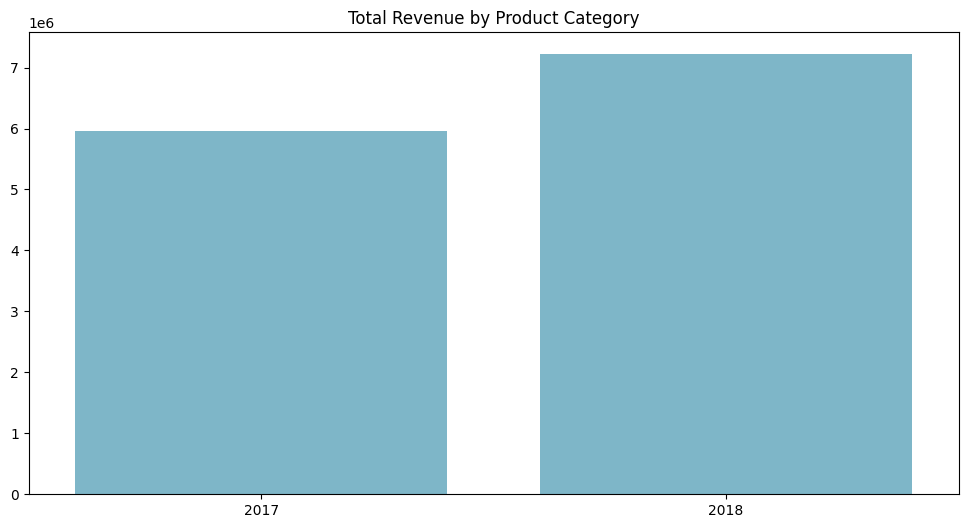

In [ ]:
plt.figure (figsize=(12,6))
colors_= ["#72BCD4"]

sns.barplot(
    y="price",
    x="order_purchase_timestamp",
    data = revenue_by_year_df,
    palette=colors_
)
plt.title('Total Revenue by Product Category')
plt.xlabel(None)
plt.ylabel(None)
plt.show()


### Pertanyaan 2: Kategori produk mana yang memberikan kontribusi pendapatan tertinggi dan terendah pada tahun 2018?

In [ ]:
category_revenue_df = (
    order_product_2018_translate_df
    .groupby('product_category_name_english')['price']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
category_revenue_df.head(10)

,product_category_name_english,price
0,health_beauty,755724.50
1,watches_gifts,687855.20
2,bed_bath_table,532358.85
3,sports_leisure,517166.26
4,computers_accessories,496269.30
5,housewares,391823.46
6,furniture_decor,381649.57
7,auto,343288.30
8,baby,250615.79
9,cool_stuff,227743.70


<ipython-input-89-4b521d6837a7>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-89-4b521d6837a7>:4: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.barplot(


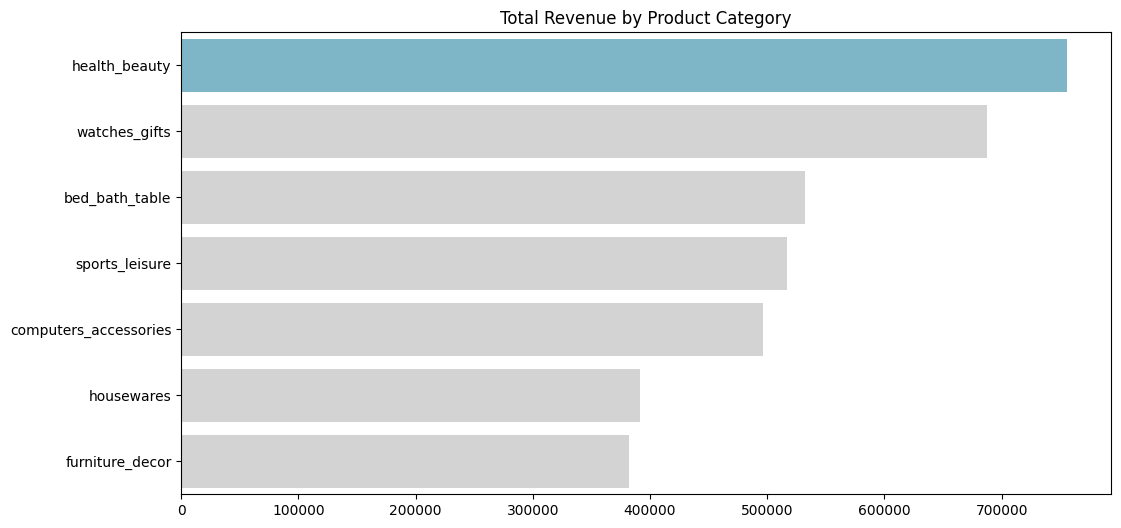

In [ ]:
plt.figure (figsize=(12,6))
colors_= ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    y="product_category_name_english",
    x="price",
    data = category_revenue_df.sort_values(by="price", ascending=False).head(7),
    palette=colors_
)
plt.title('Total Revenue by Product Category')
plt.xlabel(None)
plt.ylabel(None)
plt.show()


<ipython-input-90-207fc7d85936>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-90-207fc7d85936>:4: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.barplot(


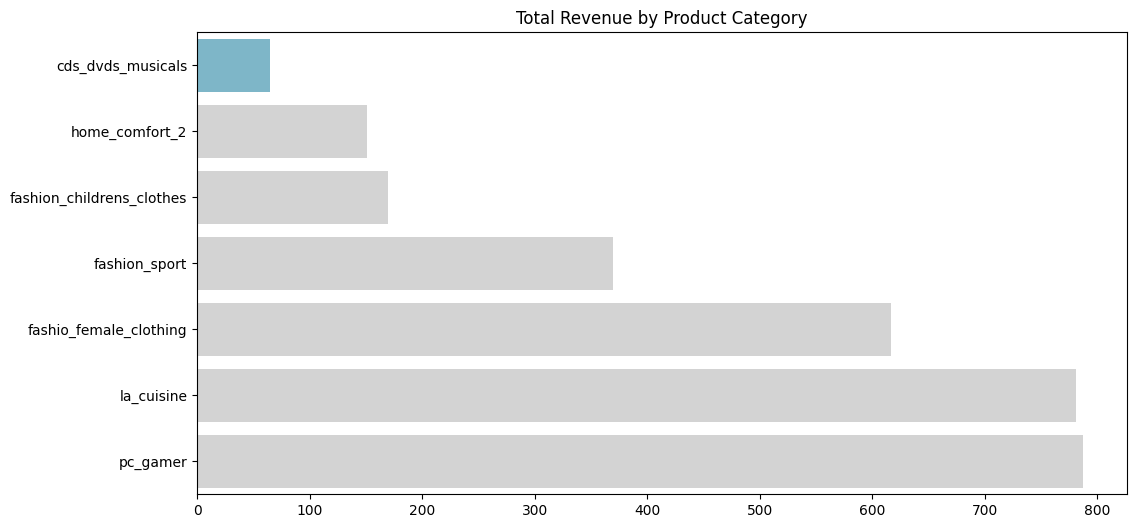

In [ ]:
plt.figure (figsize=(12,6))
colors_= ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    y="product_category_name_english",
    x="price",
    data = category_revenue_df.sort_values(by="price", ascending=True).head(7),
    palette=colors_
)
plt.title('Total Revenue by Product Category')
plt.xlabel(None)
plt.ylabel(None)
plt.show()


**Insight:**
- pendapatan pada 2018 meningkat sebanyak 21.05%
- kategori tertinggi pada tahun 2018 adalah health_beauty
- kategori terendah di tahun 2018 adalah cds_dvds_musicals

## RFM Analysis

- Bagaimana segmentasi pelanggan berdasarkan RFM (Recency, Frequency, Monetary) pada tahun 2018, dan siapa pelanggan yang termasuk dalam kategori "High-Value Customers" (nilai RFM tinggi)?

##Gabungkan data orders_df, order_payments dan costumers_df

In [ ]:
rfm_data_df= pd.merge(
    left=orders_df,
    right=order_payments_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)
rfm_data_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12


In [ ]:
rfm_data_df = pd.merge(
    left=rfm_data_df,
    right=costumers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)
rfm_data_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,credit_card,1.0,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,3.0,voucher,1.0,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2.0,voucher,1.0,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,boleto,1.0,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,credit_card,3.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103882,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,1.0,credit_card,3.0,85.08,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP
103883,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1.0,credit_card,3.0,195.00,da62f9e57a76d978d02ab5362c509660,11722,praia grande,SP
103884,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1.0,credit_card,5.0,271.01,737520a9aad80b3fbbdad19b66b37b30,45920,nova vicosa,BA
103885,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1.0,credit_card,4.0,441.16,5097a5312c8b157bb7be58ae360ef43c,28685,japuiba,RJ


In [ ]:
rfm_data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103887 entries, 0 to 103886
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103887 non-null  object        
 1   customer_id                    103887 non-null  object        
 2   order_status                   103887 non-null  object        
 3   order_purchase_timestamp       103887 non-null  datetime64[ns]
 4   order_approved_at              103712 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101999 non-null  datetime64[ns]
 6   order_delivered_customer_date  100755 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103887 non-null  datetime64[ns]
 8   payment_sequential             103886 non-null  float64       
 9   payment_type                   103886 non-null  object        
 10  payment_installments           103886 non-null  float64       
 11  

##Hitung nilai RFM

In [ ]:
tanggal = rfm_data_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_value = rfm_data_df.groupby(by="customer_unique_id").agg({
    "order_purchase_timestamp" : lambda x: (tanggal - x.max()).days,
    "order_id" : "nunique",
    "payment_value" : "sum"
}).reset_index()

rfm_value.columns = ["customer_unique_id", "recency", "frequency", "monetary"]
rfm_value.head()

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
2,0000f46a3911fa3c0805444483337064,586,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89


## Segmentasi Pelanggan Berdasarkan RFM
 bagi menjadi 5 kelompok (1 sd 5) dimana 5 adalah yg terbaik

In [ ]:
  rfm_value["R_score"] = pd.qcut(rfm_value["recency"], q=5, labels=[5, 4, 3, 2, 1])
  rfm_value["F_score"] = pd.qcut(rfm_value["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])
  rfm_value["M_score"] = pd.qcut(rfm_value["monetary"], q=5, labels=[1, 2, 3, 4, 5])

  rfm_value["RFM_score"] = rfm_value["R_score"].astype(int) + rfm_value["F_score"].astype(int) + rfm_value["M_score"].astype(int)
rfm_value.head()

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
0,0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,4,9
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,6
2,0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,4
3,0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,4
4,0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,7


##Identifikasi High_Value customer

In [ ]:
high_value_customers = rfm_value[rfm_value["RFM_score"] == 15]
high_value_customers

,customer_unique_id,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
33,00172711b30d52eea8b313a7f2cced02,66,2,244.14,5,5,5,15
448,012a218df8995d3ec3bb221828360c86,122,2,1510.38,5,5,5,15
478,013ef03e0f3f408dd9bf555e4edcdc0a,90,2,245.37,5,5,5,15
558,0178b244a5c281fb2ade54038dd4b161,82,2,259.89,5,5,5,15
740,01f2285f85a1c603eb7ef755ad311769,140,2,463.04,5,5,5,15
...,...,...,...,...,...,...,...,...
95875,ff6c9c45f6cee4ec0785650b18322d73,91,1,1568.72,5,5,5,15
95926,ff8eddc3ff272a5724e2ac6635cb7df2,109,1,991.74,5,5,5,15
95967,ffa323b33234124b58b25511035c2855,126,1,301.34,5,5,5,15
96064,ffe96c782a5bc522bd8bad3bc638981a,80,1,245.22,5,5,5,15


#Visualisasi


In [ ]:
rfm_value.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   customer_unique_id  96096 non-null  object  
 1   recency             96096 non-null  int64   
 2   frequency           96096 non-null  int64   
 3   monetary            96096 non-null  float64 
 4   R_score             96096 non-null  category
 5   F_score             96096 non-null  category
 6   M_score             96096 non-null  category
 7   RFM_score           96096 non-null  int64   
dtypes: category(3), float64(1), int64(3), object(1)
memory usage: 3.9+ MB


In [ ]:
rfm_value['F_score'] = rfm_value['F_score'].astype(int)
rfm_value['M_score'] = rfm_value['M_score'].astype(int)

In [ ]:
rfm_point = rfm_value.groupby(by="RFM_score").agg({
    "customer_unique_id" : "nunique"
}).sort_values(by="RFM_score", ascending=False).reset_index()
rfm_point.head()

,RFM_score,customer_unique_id
0,15,1057
1,14,2493
2,13,4729
3,12,7677
4,11,11209


<Axes: xlabel='RFM_score', ylabel='customer_unique_id'>

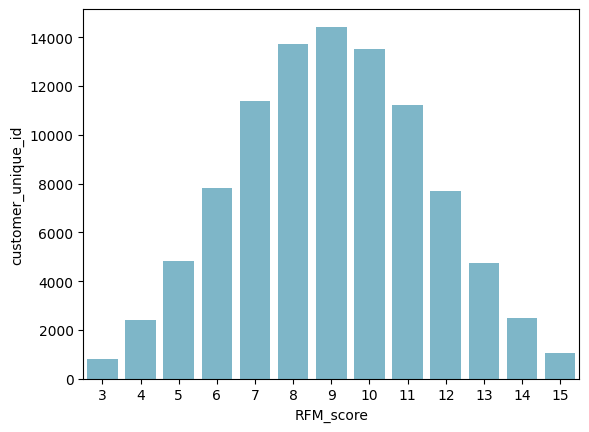

In [ ]:
sns.barplot(
    x="RFM_score",
    y="customer_unique_id",
    data=rfm_point,
    color="#72BCD4"
)

## Geospatial Analysis

- Bagaimana distribusi geografis asal penjual terbanyak?

#explore data geolocation

In [ ]:
!pip install folium
!pip install geopandas contextily


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.9/110.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 78.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 96.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.4/125.4 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.8 MB/s eta 0:00:00


In [ ]:
import folium
from folium.plugins import HeatMap
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from shapely.geometry import Point

In [ ]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


#explore data seller_df


In [ ]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


#explore data seller dan geolocation

In [ ]:
seller_geo_df = pd.merge(
    left=sellers_df,
    right=geolocation_df,
    how="left",
    left_on="seller_zip_code_prefix",
    right_on="geolocation_zip_code_prefix"
)
seller_geo_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.898536,-47.063125,campinas,SP
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.895499,-47.061944,campinas,SP
2,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.891740,-47.060820,campinas,SP
3,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.895762,-47.066144,campinas,SP
4,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.896154,-47.062431,campinas,SP


In [ ]:
seller_geo_df.drop(columns=["geolocation_city", "geolocation_state"], inplace=True)
seller_geo_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.898536,-47.063125
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.895499,-47.061944
2,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.891740,-47.060820
3,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.895762,-47.066144
4,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP,13023.0,-22.896154,-47.062431


In [ ]:
# Revisi
seller_geo_df.groupby(by=["seller_city"]).agg({
    "seller_id" : "nunique",
}).sort_values(by="seller_id", ascending=False)

,seller_id
seller_city,
sao paulo,694
curitiba,127
rio de janeiro,96
belo horizonte,68
ribeirao preto,52
...,...
tambau,1
taruma,1
teixeira soares,1


In [ ]:
seller_geo_df.groupby(by=["geolocation_lat", "geolocation_lng"]).agg({
    "seller_id" : "nunique",
}).sort_values(by="seller_id", ascending=False)

,,seller_id
geolocation_lat,geolocation_lng,
-21.754867,-48.838906,49
-21.753873,-48.827806,49
-21.753991,-48.832556,49
-21.754963,-48.822699,49
-21.753223,-48.826596,49
...,...,...
-2.508349,-44.246014,1
-2.507086,-44.249798,1
-2.507006,-44.246491,1


ubah jadi dataframe

In [ ]:
seller_map_df = seller_geo_df.groupby(by=["geolocation_lat", "geolocation_lng"]).agg({
    "seller_id" : "nunique",
}).sort_values(by="seller_id", ascending=False).reset_index()
seller_map_df.head()

,geolocation_lat,geolocation_lng,seller_id
0,-21.754867,-48.838906,49
1,-21.753873,-48.827806,49
2,-21.753991,-48.832556,49
3,-21.754963,-48.822699,49
4,-21.753223,-48.826596,49


In [ ]:
# Tentukan titik tengah peta berdasarkan rata-rata koordinat
map_center = [seller_map_df['geolocation_lat'].mean(), seller_map_df['geolocation_lng'].mean()]

# Buat peta dengan Folium
seller_map = folium.Map(location=map_center, zoom_start=12)

# Tambahkan Heatmap ke peta
heat_data = seller_map_df[['geolocation_lat', 'geolocation_lng']].values.tolist()
HeatMap(heat_data).add_to(seller_map)


seller_map

## Clustering (Manual Grouping)

- Bagaimana pengelompokan produk berdasarkan harga dan berat untuk mengoptimalkan strategi penetapan harga dan pengiriman?

menggabungkan data orders_items_df dan product_df



In [ ]:
product_orders_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

product_orders_df.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69,utilidades_domesticas,36.0,558.0,1.0,450.0,24.0,8.0,15.0
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85,telefonia,52.0,815.0,1.0,200.0,27.0,5.0,20.0
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75,ferramentas_jardim,39.0,1310.0,3.0,13805.0,35.0,75.0,45.0
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,beleza_saude,59.0,493.0,1.0,2000.0,30.0,12.0,16.0
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40,livros_tecnicos,52.0,1192.0,1.0,850.0,29.0,3.0,21.0


In [ ]:
product_orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_id                    112650 non-null  object 
 1   order_item_id               112650 non-null  int64  
 2   product_id                  112650 non-null  object 
 3   seller_id                   112650 non-null  object 
 4   shipping_limit_date         112650 non-null  object 
 5   price                       112650 non-null  float64
 6   freight_value               112650 non-null  float64
 7   product_category_name       111046 non-null  object 
 8   product_name_lenght         111046 non-null  float64
 9   product_description_lenght  111046 non-null  float64
 10  product_photos_qty          111046 non-null  float64
 11  product_weight_g            111046 non-null  float64
 12  product_length_cm           111046 non-null  float64
 13  product_height

In [ ]:
product_orders_df.describe()

,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,112650.000000,112650.000000,112650.000000,111046.000000,111046.000000,111046.000000,111046.000000,111046.000000,111046.000000,111046.000000
mean,1.197834,120.653739,19.990320,48.775877,787.866335,2.209706,2099.979657,30.211003,16.626362,23.041956
std,0.705124,183.633928,15.806405,10.025570,652.138503,1.721445,3754.785226,16.189352,13.467460,11.716659
min,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,1.000000,39.900000,13.080000,42.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,1.000000,134.900000,21.150000,57.000000,987.000000,3.000000,1800.000000,38.000000,20.000000,30.000000
max,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [ ]:
product_data = product_orders_df[["product_id", "price", "product_weight_g", "freight_value"]]
product_data.head()


,product_id,price,product_weight_g,freight_value
0,4244733e06e7ecb4970a6e2683c13e61,58.90,650.0,13.29
1,e5f2d52b802189ee658865ca93d83a8f,239.90,30000.0,19.93
2,c777355d18b72b67abbeef9df44fd0fd,199.00,3050.0,17.87
3,7634da152a4610f1595efa32f14722fc,12.99,200.0,12.79
4,ac6c3623068f30de03045865e4e10089,199.90,3750.0,18.14


In [ ]:
product_data.describe()

,price,product_weight_g,freight_value
count,112650.000000,111046.000000,112650.000000
mean,120.653739,2099.979657,19.990320
std,183.633928,3754.785226,15.806405
min,0.850000,0.000000,0.000000
25%,39.900000,300.000000,13.080000
50%,74.990000,700.000000,16.260000
75%,134.900000,1800.000000,21.150000
max,6735.000000,40425.000000,409.680000


##Kategorisasi

Harga

In [ ]:
product_data['price_category'] = pd.cut(
    product_data['price'],
    bins=[0, 40, 75, 135, float('inf')],
    labels=['low', 'medium', 'high', 'very_high']
)
product_data

<ipython-input-115-ed30c2201dc7>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_data['price_category'] = pd.cut(


,product_id,price,product_weight_g,freight_value,price_category
0,4244733e06e7ecb4970a6e2683c13e61,58.90,650.0,13.29,medium
1,e5f2d52b802189ee658865ca93d83a8f,239.90,30000.0,19.93,very_high
2,c777355d18b72b67abbeef9df44fd0fd,199.00,3050.0,17.87,very_high
3,7634da152a4610f1595efa32f14722fc,12.99,200.0,12.79,low
4,ac6c3623068f30de03045865e4e10089,199.90,3750.0,18.14,very_high
...,...,...,...,...,...
112645,4aa6014eceb682077f9dc4bffebc05b0,299.99,10150.0,43.41,very_high
112646,32e07fd915822b0765e448c4dd74c828,350.00,8950.0,36.53,very_high
112647,72a30483855e2eafc67aee5dc2560482,99.90,967.0,16.95,high
112648,9c422a519119dcad7575db5af1ba540e,55.99,100.0,8.72,medium


Berat

In [ ]:
product_data['weight_category'] = pd.cut(
    product_data['product_weight_g'],
    bins=[0, 300, 700, 1800, float('inf')],
    labels=['light', 'medium', 'heavy', 'very_heavy']
)
product_data

<ipython-input-116-efdaf896f717>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  product_data['weight_category'] = pd.cut(


,product_id,price,product_weight_g,freight_value,price_category,weight_category
0,4244733e06e7ecb4970a6e2683c13e61,58.90,650.0,13.29,medium,medium
1,e5f2d52b802189ee658865ca93d83a8f,239.90,30000.0,19.93,very_high,very_heavy
2,c777355d18b72b67abbeef9df44fd0fd,199.00,3050.0,17.87,very_high,very_heavy
3,7634da152a4610f1595efa32f14722fc,12.99,200.0,12.79,low,light
4,ac6c3623068f30de03045865e4e10089,199.90,3750.0,18.14,very_high,very_heavy
...,...,...,...,...,...,...
112645,4aa6014eceb682077f9dc4bffebc05b0,299.99,10150.0,43.41,very_high,very_heavy
112646,32e07fd915822b0765e448c4dd74c828,350.00,8950.0,36.53,very_high,very_heavy
112647,72a30483855e2eafc67aee5dc2560482,99.90,967.0,16.95,high,heavy
112648,9c422a519119dcad7575db5af1ba540e,55.99,100.0,8.72,medium,light


##Pengelompokan

In [ ]:
group_data = product_data.groupby(["price_category", "weight_category"]).agg({
    "freight_value": "mean",
    "price": "mean",
}).reset_index()
group_data

<ipython-input-117-5af86242b6d7>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_data = product_data.groupby(["price_category", "weight_category"]).agg({


,price_category,weight_category,freight_value,price
0,low,light,14.001342,24.069449
1,low,medium,14.245239,28.262785
2,low,heavy,15.614852,31.426737
3,low,very_heavy,18.002404,29.853867
4,medium,light,14.796407,54.914148
5,medium,medium,15.876074,56.370387
6,medium,heavy,16.950496,57.924319
7,medium,very_heavy,20.594839,61.350478
8,high,light,15.699183,97.281741
9,high,medium,16.496758,102.779388


##Visualisasi

Heatmap

<ipython-input-118-5138f7647f83>:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = group_data.pivot_table(


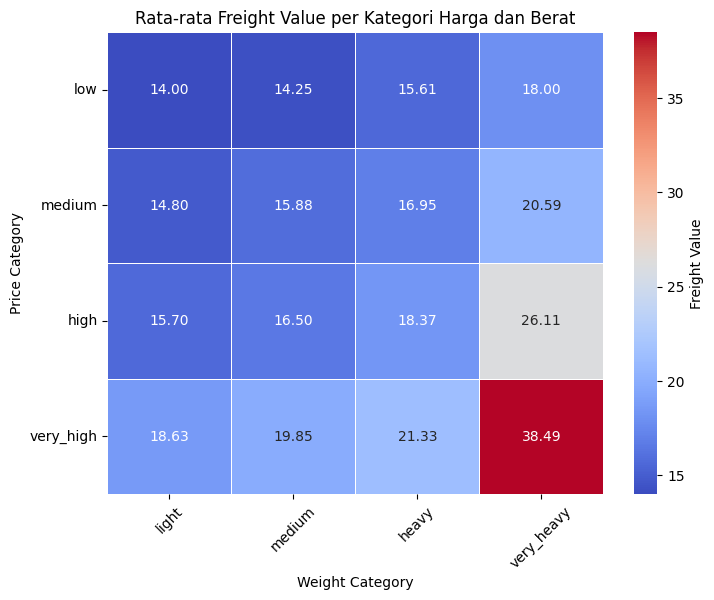

In [ ]:
# Pivot table untuk heatmap
heatmap_data = group_data.pivot_table(
    index='price_category',
    columns='weight_category',
    values='freight_value',
    aggfunc='mean'
)

# Buat heatmap dengan seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Freight Value'})

plt.title('Rata-rata Freight Value per Kategori Harga dan Berat', fontsize=12)
plt.xlabel("Weight Category")
plt.ylabel("Price Category")
plt.xticks(rotation=45)  # Putar label sumbu X agar lebih mudah dibaca
plt.yticks(rotation=0)
plt.show()

<ipython-input-119-f5bdceb800cc>:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = group_data.pivot_table(


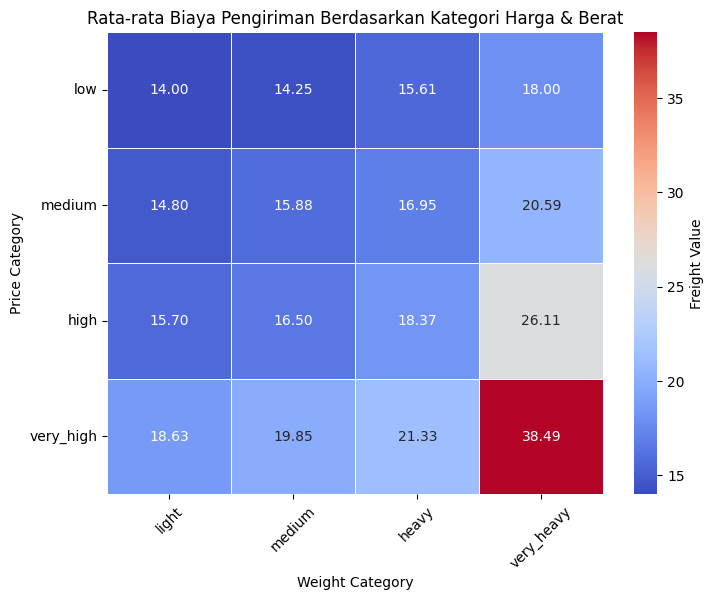

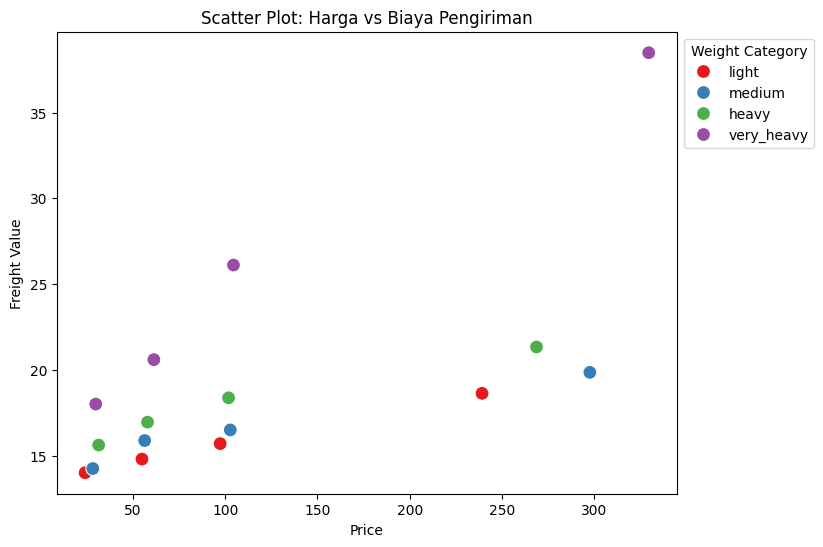

In [ ]:
# ---- Heatmap Biaya Pengiriman ----
heatmap_data = group_data.pivot_table(
    index='price_category',
    columns='weight_category',
    values='freight_value',
    aggfunc='mean'
)

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5, cbar_kws={'label': 'Freight Value'})
plt.title('Rata-rata Biaya Pengiriman Berdasarkan Kategori Harga & Berat')
plt.xlabel("Weight Category")
plt.ylabel("Price Category")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

# ---- Scatter Plot Harga vs Biaya Pengiriman ----
plt.figure(figsize=(8, 6))
sns.scatterplot(x="price", y="freight_value", hue="weight_category", data=group_data, palette="Set1", s=100)
plt.title("Scatter Plot: Harga vs Biaya Pengiriman")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.legend(title="Weight Category", bbox_to_anchor=(1, 1))
plt.show()


Bar Plot

<ipython-input-120-035009c41054>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


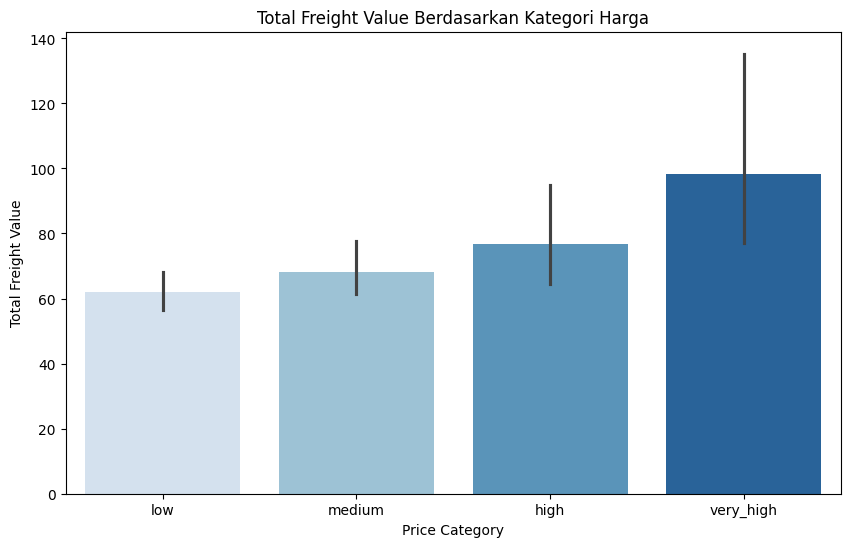

<ipython-input-120-035009c41054>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


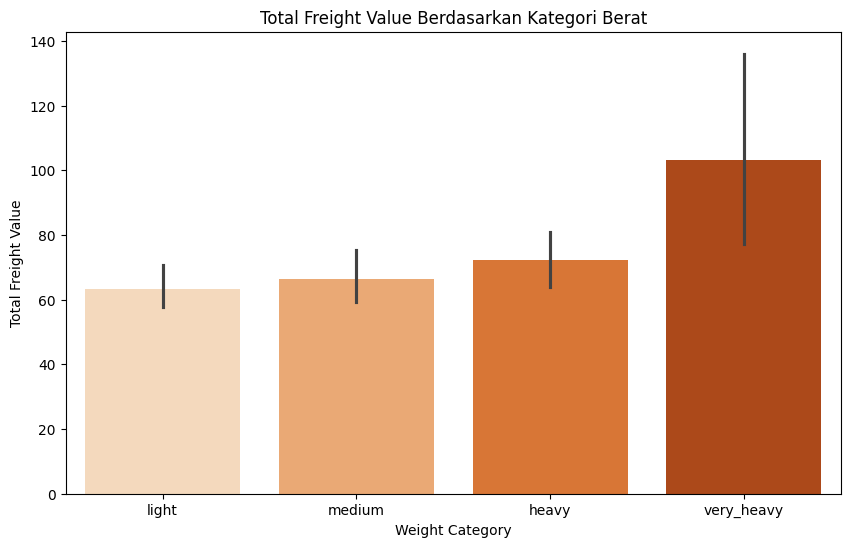

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="price_category",
    y="freight_value",
    data=group_data,
    palette="Blues",
    estimator=sum)
plt.title("Total Freight Value Berdasarkan Kategori Harga")
plt.xlabel("Price Category")
plt.ylabel("Total Freight Value")
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    x="weight_category",
    y="freight_value",
    data=group_data,
    palette="Oranges",
    estimator=sum)
plt.title("Total Freight Value Berdasarkan Kategori Berat")
plt.xlabel("Weight Category")
plt.ylabel("Total Freight Value")
plt.show()

## Conclusion

Revisi
<br>
-  Bagaimana pendapatan dari e commmerce yang berhasil dihasilkan pada tahun 2018? dan bagaimana pertumbuhannya dibandingkan dengan tahun 2017??<br>
Berdasarkan hasil Analisi ditemukan bahwa pendapatan mengalami pertumbuhan dari tahun 2017 ke tahun 2018
--> Dari hasil visualisasi di dapatkan hasil di tahun 2018 sebesar 7386050.80 peso dan kenaikan pada tahun 2018 sebesar 1,230,243.82 peso dari tahun 2017 yang berjumlah 6155806.98 peso.
-  Kategori produk mana yang memberikan kontribusi pendapatan tertinggi dan terendah pada tahun 2018?
--> Kontribusi tertinggi didapatkan oleh kategory Health Beauty mencapai 755724.50 dan kategori dengan kontribusi terendah di dapatkan oleh cds_dvds_musicals yang hanya mendapat 65 peso saja. ini dapat menjadi acuan bagi para penjual untuk apa saja kategori barang yang sebaiknya mereka jual.
saran :  Produk dengan harga tinggi sebaiknya diberikan opsi diskon atau promo cicilan tanpa bunga untuk menarik lebih banyak pelanggan.
Produk yang kurang laku dapat diberikan strategi pemasaran yang lebih agresif.

<br>

- Berdasarkan analisis RFM didapatkan High Value Costumer dengan beberapa id. Mereka mendapat skor sebesar 15 poin. namun lebih banyak costumer yang mendapat poin 9 dalam RFM poin ini.

-Berdasarkan Geospasial kota san paulo memiliki penjual terbanyak dilihat dari heatmap dengan jumlah 694 orang penjual yang tersebar di kota tersebut. ini menandakan bahwa di sana kemungkinan terjadi persaingan yang cukup tinggi dan data ini dapat digunakan untuk menilai untuk para penjual yang baru dan ingin berjualan di sana
saran : Mengingat sebagian besar pelanggan berasal dari São Paulo, ada peluang besar untuk memperluas pasar ke wilayah lain yang memiliki pelanggan potensial.

- Berdasarkan Hasil Clustering kita dapat melihat bahwa berat barang dan harga barang sangat memengaruhi harga pengiriman (freight_value) semakin tinggi harga dan semakin berat sebuah barang maka akan semakin mahal juga biaya pengiriman

Berdasarkan eksplorasi dan analisis data yang telah dilakukan, berikut adalah beberapa temuan utama yang dapat dijelaskan secara lebih rinci:

1. Validasi dan Pembersihan Data
Dari total data pesanan, hanya 96.478 pesanan yang dapat digunakan untuk analisis. Hal ini disebabkan oleh adanya pesanan yang tidak valid atau memiliki status yang tidak dapat diproses.
Data pesanan dimulai dari tahun 2016 hingga 2018, tetapi jumlah pesanan di tahun 2016 sangat sedikit, sehingga berpotensi mengganggu akurasi analisis tren. Oleh karena itu, data tahun 2016 telah dihapus untuk fokus pada 2017 dan 2018.
Setelah penggabungan beberapa dataset, ditemukan banyak data kosong, terutama pada kategori produk. Proses cleaning data telah dilakukan, termasuk penghapusan data kosong dan pengisian kategori produk yang hilang.
2. Tren Jumlah dan Nilai Pesanan
Pada tahun 2017 dan 2018, terjadi peningkatan pendapatan sebesar 1.230.243,82 peso. Hal ini menunjukkan adanya pertumbuhan bisnis yang signifikan, yang bisa dianalisis lebih lanjut untuk memahami faktor yang berkontribusi terhadap peningkatan ini.
Sebagian besar pesanan hanya berisi satu produk, tetapi ada juga pesanan dengan lebih banyak item, yang mengindikasikan adanya variasi perilaku pelanggan.
Produk dengan harga tertinggi mencapai 239,90 peso, sedangkan produk dengan harga terendah hanya 12,99 peso, menunjukkan adanya diversifikasi harga dalam katalog produk.
3. Analisis Kategori Produk Terlaris
Kategori produk terlaris berdasarkan total nilai penjualan adalah Beleza_saude (Health & Beauty), dengan total nilai transaksi mencapai 755.724,50 peso.
Kategori dengan penjualan terendah adalah CDs, DVDs, Musicals, yang hanya mencatat transaksi sebesar 65 peso. Hal ini mengindikasikan bahwa produk fisik media mungkin mengalami penurunan permintaan dibandingkan dengan kategori lainnya.
Dengan memahami tren kategori produk, bisnis dapat menyesuaikan strategi pemasaran, misalnya dengan meningkatkan promosi pada kategori yang sedang naik daun atau mengurangi stok pada kategori yang kurang laku.
4. Metode Pembayaran dan Perilaku Konsumen
Kartu kredit merupakan metode pembayaran yang paling sering digunakan, menunjukkan bahwa pelanggan lebih memilih transaksi berbasis kredit dibanding metode lain.
Banyak pelanggan menggunakan sistem cicilan, dengan rata-rata 8 kali cicilan, yang menunjukkan bahwa harga produk yang lebih tinggi masih dapat diterima selama tersedia opsi pembayaran bertahap.
Bisnis dapat mempertimbangkan untuk menawarkan promosi cicilan tanpa bunga atau cashback guna meningkatkan minat pelanggan dalam bertransaksi.
5. Biaya Pengiriman dan Tantangan Logistik
Biaya pengiriman yang dikenakan kepada pelanggan bervariasi, berkisar antara 12,79 hingga 19,93 peso.
Beberapa pesanan mengalami keterlambatan pengiriman, yang dapat berdampak pada kepuasan pelanggan. Oleh karena itu, perlu ada optimalisasi dalam sistem logistik untuk memastikan bahwa produk dapat dikirim tepat waktu dengan biaya yang efisien.
Rekomendasi Berdasarkan Analisis
Optimasi Kategori Produk

Fokus pada kategori Health & Beauty, yang memiliki performa penjualan tertinggi.
Evaluasi ulang kategori dengan performa rendah seperti CDs, DVDs, Musicals, apakah masih layak dipertahankan atau perlu inovasi dalam strategi pemasaran.
Strategi Peningkatan Penjualan

Memanfaatkan tren peningkatan pendapatan di 2018 dengan strategi pemasaran yang lebih agresif, seperti diskon, bundling produk, atau program loyalitas pelanggan.
Meningkatkan promosi produk dengan harga tinggi dengan menawarkan program cicilan yang lebih fleksibel.
Perbaikan Logistik dan Pengiriman

Mengidentifikasi penyebab keterlambatan pengiriman dan mengoptimalkan sistem logistik.
Menawarkan program gratis ongkir atau diskon biaya pengiriman untuk meningkatkan kepuasan pelanggan.
Analisis Lanjutan

Menganalisis lebih dalam tentang perilaku pelanggan berdasarkan wilayah geografis untuk menargetkan pemasaran yang lebih efektif.
Menggunakan metode Machine Learning untuk memprediksi tren permintaan produk di masa mendatang.
Kesimpulan Akhir
Analisis ini menunjukkan bahwa bisnis mengalami pertumbuhan yang positif, terutama dari 2017 ke 2018. Kategori Health & Beauty menjadi produk unggulan, sementara beberapa kategori mengalami penurunan minat. Dengan strategi yang tepat dalam pemasaran, metode pembayaran, dan logistik, bisnis dapat semakin meningkatkan pendapatan serta kepuasan pelanggan.

